<div style="display:flex; align-items:center; justify-content:space-between; padding:10px 0;">
  <img src="https://admision.utem.cl/wp-content/uploads/2021/10/logo-frase-1.png"
       alt="Logo UTEM" width="260">
  <div style="text-align:right; font-size:13px; color:#555;">
    <strong>INFB6093 — Procesamiento de Lenguaje Natural</strong><br>
    Universidad Tecnológica Metropolitana — Facultad de Ingeniería<br>
    Docente: Jaime Jiménez Ruiz &lt;jjimenezru@utem.cl&gt;
  </div>
</div>

<hr>

## Lab 08 (B1 + B2) — EDA Actualizado + Baseline Clásico · Trabajo en Equipo

---

---

## 0 · Configuración del equipo




In [1]:
# ==============================================================================
# 0 · CONFIGURACIÓN DEL EQUIPO — HOMO-LAT25 (MÉTRICAS OFICIALES)
# ==============================================================================

EQUIPO_ID        = "EQUIPO_05"
INTEGRANTES      = ["Martínez, Felipe", "Zamorano, Benjamín"]
NOMBRE_PROYECTO  = "Clasificación multiclase de tweets en español latinoamericano relacionados con la comunidad LGBTQ+"

# Dataset
DATASET_ID       = "homolat25"
DATASET_FUENTE   = "https://www.codabench.org/competitions/5613/"
DATASET_LICENCIA = "Uso Académico / IberLEF 2025"

# Tarea
TASK_TYPE        = "classification_multiclass"
TEXT_FIELD       = "post content"
LABEL_FIELD      = "label"
LABEL_SPACE      = ["NEG", "NEU", "POS"]

# Métricas y parámetros heredados de la exploración base
METRICA_PRINCIPAL   = "F1 macro"
BASELINE_TRIVIAL_F1 = 0.2540  # F1 macro aproximado de la regla trivial (Zero Rule)
MAX_LENGTH_DECISION = 262     # Decisión estratégica para evitar truncamiento en Transformers

CAMBIO = None

---

## 1 · Setup del entorno




In [2]:
# ==============================================================================
# 1 · SETUP DEL ENTORNO — DEPENDENCIAS Y CONFIGURACIÓN COMPLETA (VERSIÓN LIMPIA)
# ==============================================================================
import sys
print(f" Versión de Python en ejecución: {sys.version}")
print(" Aplicando parches e instalando librerías en silencio (Espere un momento)...")

# 1. Silenciar por completo el instalador pip y el CLI de la terminal
!pip install -q --root-user-action=ignore typer==0.9.4 click==8.1.7 > /dev/null 2>&1
!pip install -q --root-user-action=ignore --upgrade spacy wordcloud datasets > /dev/null 2>&1
!pip install -q --root-user-action=ignore scikit-learn matplotlib seaborn > /dev/null 2>&1

# 2. Descargar el modelo grande de spaCy directo al núcleo del sistema
!pip install -q --root-user-action=ignore https://github.com/explosion/spacy-models/releases/download/es_core_news_lg-3.7.0/es_core_news_lg-3.7.0.tar.gz > /dev/null 2>&1
print(" Todas las instalaciones de dependencias base se completaron con éxito.")

# 3. Importaciones científicas estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter, defaultdict
import string
import zipfile
import os
import glob
import warnings
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# Bloqueo drástico de advertencias de Python y de la terminal de Linux
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Ajustes estéticos de la suite gráfica del Laboratorio
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 11

# Componentes de modelamiento clásico requeridos para la Sección 5
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

# 4. Carga controlada del pipeline de Procesamiento de Lenguaje Natural (spaCy)
import spacy
try:
    nlp = spacy.load("es_core_news_lg")
    print(" Modelo 'es_core_news_lg' cargado exitosamente en el núcleo.")
except OSError:
    import es_core_news_lg
    nlp = es_core_news_lg.load()
    print(" Modelo 'es_core_news_lg' inicializado mediante fallback de importación.")

# 5. Configuración estricta de la semilla aleatoria para asegurar reproducibilidad
SEED = 42
np.random.seed(SEED)

# 6. Despliegue del reporte formal consolidado
print("\n" + "="*45)
print("=== REPORTE DE VERSIONES CONFIGURADAS ===")
print("="*45)
print(f"   Versión de Pandas:     {pd.__version__}")
print(f"   Versión de NumPy:      {np.__version__}")
print(f"   Versión de Matplotlib: {matplotlib.__version__}")
print(f"   Versión de Seaborn:    {sns.__version__}")
print(f"   Versión de SpaCy:      {spacy.__version__}")
import sklearn
print(f"   Versión de Scikit-Learn:{sklearn.__version__}")
print("="*45)

 Versión de Python en ejecución: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
 Aplicando parches e instalando librerías en silencio (Espere un momento)...
 Todas las instalaciones de dependencias base se completaron con éxito.
 Modelo 'es_core_news_lg' cargado exitosamente en el núcleo.

=== REPORTE DE VERSIONES CONFIGURADAS ===
   Versión de Pandas:     2.2.2
   Versión de NumPy:      1.26.4
   Versión de Matplotlib: 3.10.0
   Versión de Seaborn:    0.13.2
   Versión de SpaCy:      3.7.5
   Versión de Scikit-Learn:1.6.1


---

## 2 · Carga y esquema actualizado



In [3]:
# ==============================================================================
# 2 · CARGA Y ESQUEMA INTEGRADO DEL DATASET (DESCARGA + ANÁLISIS OFICIAL)
# ==============================================================================
print("[INFO] Iniciando descarga automática del corpus HOMO-LAT25 desde GitHub...")

# 1. Configuración de nombres y limpieza de residuos previos para evitar fallas
ZIP_PRINCIPAL = "HOMO-LAT25-Tweets-ES.zip"
CARPETA_SALIDA = "dataset"

if os.path.exists(ZIP_PRINCIPAL):
    !rm HOMO-LAT25-Tweets-ES.zip
if os.path.exists(CARPETA_SALIDA):
    !rm -rf dataset

# 2. Descarga directa desde el repositorio oficial de GitHub del equipo
!wget -q "https://github.com/Thefelixctm/PLN/raw/main/Miniproyecto/HOMO-LAT25-Tweets-ES.zip"
print("[OK] ZIP principal descargado con éxito.")

# 3. Extraer ZIP principal en la carpeta del dataset
os.makedirs(CARPETA_SALIDA, exist_ok=True)
with zipfile.ZipFile(ZIP_PRINCIPAL, "r") as zip_ref:
    zip_ref.extractall(CARPETA_SALIDA)
print("[OK] ZIP principal extraído.")

# 4. Buscar todos los ZIP internos de forma recursiva y extraerlos (Estructura anidada)
zip_internos = glob.glob(f"{CARPETA_SALIDA}/**/*.zip", recursive=True)
for zip_path in zip_internos:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(CARPETA_SALIDA)
print("[OK] Todos los ZIP internos fueron extraídos de forma reciclada.")

# 5. Cargar todos los archivos CSV disponibles en el entorno según vuestro diseño
df_train = pd.read_csv("dataset/train_homolat25.csv")
df_dev = pd.read_csv("dataset/dev.csv")
df_test_task1 = pd.read_csv("dataset/dataset_task1.csv")
df_test_task2 = pd.read_csv("dataset/dataset_task2.csv")

# Sincronización real de las variables de la pauta con sus datos reales
TEXT_FIELD  = "post content"
LABEL_FIELD = "label"
LABEL_SPACE = sorted(df_train[LABEL_FIELD].dropna().unique().tolist())
DATASET_ID  = "homolat25"

# 6. Reportar las dimensiones de TODOS los conjuntos (Shapes oficiales)
print("\n=== 1. FORMA DEL DATASET (SPLITS TOTALES) ===")
print(f"Conjunto de ENTRENAMIENTO (Train) : {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Conjunto de VALIDACIÓN (Dev)      : {df_dev.shape[0]} filas, {df_dev.shape[1]} columnas")
print(f"Conjunto de PRUEBA (Test Task 1)  : {df_test_task1.shape[0]} filas, {df_test_task1.shape[1]} columnas (Sin etiquetas)")
print(f"Conjunto de PRUEBA (Test Task 2)  : {df_test_task2.shape[0]} filas, {df_test_task2.shape[1]} columnas (Sin etiquetas)")

# 7. Mostrar el esquema técnico (usando Train como base)
print("\n=== 2. ESQUEMA TÉCNICO (COLUMNAS Y TIPOS EN TRAIN) ===")
print(df_train.dtypes)

# 8. Validación de consistencia con las variables globales del curso
assert TEXT_FIELD in df_train.columns, f"Error: La columna de texto '{TEXT_FIELD}' no existe."
assert LABEL_FIELD in df_train.columns, f"Error: La columna de etiqueta '{LABEL_FIELD}' no existe."
print("\n[OK] Validación exitosa: Las columnas coinciden con TEXT_FIELD y LABEL_FIELD.")

# 9. Selección y despliegue de 3 instancias cualitativamente representativas (de Train)
print("\n=== 3. MUESTRA DE INSTANCIAS REPRESENTATIVAS ===")

# Instancia A: Un caso claro de polaridad Negativa (NEG)
instancia_neg = df_train[df_train[LABEL_FIELD] == 'NEG'].iloc[0]
print(f"\n [INSTANCIA A - CLASE NEGATIVA]")
print(f"ID: {instancia_neg['id']} | País: {instancia_neg['country']} | Keyword: {instancia_neg['keyword']}")
print(f"Contenido del Post:\n- {instancia_neg[TEXT_FIELD]}")

# Instancia B: Un caso claro de polaridad Positiva (POS)
instancia_pos = df_train[df_train[LABEL_FIELD] == 'POS'].iloc[0]
print(f"\n [INSTANCIA B - CLASE POSITIVA]")
print(f"ID: {instancia_pos['id']} | País: {instancia_pos['country']} | Keyword: {instancia_pos['keyword']}")
print(f"Contenido del Post:\n- {instancia_pos[TEXT_FIELD]}")

# Instancia C: El tweet más largo del dataset de entrenamiento
idx_max_largo = df_train[TEXT_FIELD].str.len().idxmax()
instancia_larga = df_train.loc[idx_max_largo]
print(f"\n [INSTANCIA C - CASO EXTREMO / MÁS LARGO]")
print(f"ID: {instancia_larga['id']} | País: {instancia_larga['country']} | Etiqueta: {instancia_larga[LABEL_FIELD]}")
print(f"Contenido (Longitud: {len(instancia_larga[TEXT_FIELD])} caracteres):\n- {instancia_larga[TEXT_FIELD]}")

print("\n" + "="*50)

[INFO] Iniciando descarga automática del corpus HOMO-LAT25 desde GitHub...
[OK] ZIP principal descargado con éxito.
[OK] ZIP principal extraído.
[OK] Todos los ZIP internos fueron extraídos de forma reciclada.

=== 1. FORMA DEL DATASET (SPLITS TOTALES) ===
Conjunto de ENTRENAMIENTO (Train) : 5767 filas, 5 columnas
Conjunto de VALIDACIÓN (Dev)      : 1443 filas, 5 columnas
Conjunto de PRUEBA (Test Task 1)  : 3588 filas, 4 columnas (Sin etiquetas)
Conjunto de PRUEBA (Test Task 2)  : 5475 filas, 4 columnas (Sin etiquetas)

=== 2. ESQUEMA TÉCNICO (COLUMNAS Y TIPOS EN TRAIN) ===
id              object
country         object
keyword         object
post content    object
label           object
dtype: object

[OK] Validación exitosa: Las columnas coinciden con TEXT_FIELD y LABEL_FIELD.

=== 3. MUESTRA DE INSTANCIAS REPRESENTATIVAS ===

 [INSTANCIA A - CLASE NEGATIVA]
ID: A3307 | País: Argentina | Keyword: transexuales
Contenido del Post:
- Es que no es respetar su nombre, es como dijo otro com

---

## 3 · EDA Actualizado


### ── 3.1 Balance de etiquetas ────────────────────────

=== BALANCE DE ETIQUETAS POR SPLIT ===
split etiqueta  frecuencia  porcentaje
train      NEG        1960       33.99
train      NEU        3174       55.04
train      POS         633       10.98
  dev      NEG         475       32.92
  dev      NEU         888       61.54
  dev      POS          80        5.54


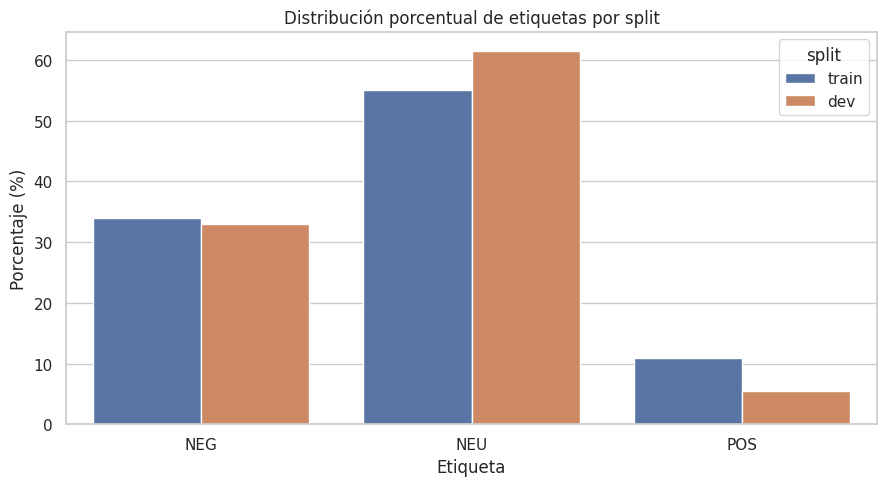


=== BASELINE PISO ===
Clase mayoritaria en train: NEU
F1 macro piso evaluado en dev: 0.2540


In [4]:
def resumen_etiquetas(df, nombre_split):
    counts = df[LABEL_FIELD].value_counts().reindex(LABEL_SPACE, fill_value=0)
    pct = counts / len(df) * 100

    resumen = pd.DataFrame({
        "split": nombre_split,
        "etiqueta": counts.index,
        "frecuencia": counts.values,
        "porcentaje": pct.round(2).values
    })

    return resumen

balance_train = resumen_etiquetas(df_train, "train")
balance_dev = resumen_etiquetas(df_dev, "dev")

balance_total = pd.concat([balance_train, balance_dev], ignore_index=True)

print("=== BALANCE DE ETIQUETAS POR SPLIT ===")
print(balance_total.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=balance_total,
    x="etiqueta",
    y="porcentaje",
    hue="split"
)

plt.title("Distribución porcentual de etiquetas por split")
plt.xlabel("Etiqueta")
plt.ylabel("Porcentaje (%)")
plt.tight_layout()
plt.show()

clase_mayoritaria = df_train[LABEL_FIELD].value_counts().idxmax()

y_true_dev = df_dev[LABEL_FIELD]
y_pred_dev_zero = [clase_mayoritaria] * len(df_dev)

f1_piso_dev = f1_score(
    y_true_dev,
    y_pred_dev_zero,
    average="macro",
    labels=LABEL_SPACE,
    zero_division=0
)

print("\n=== BASELINE PISO ===")
print(f"Clase mayoritaria en train: {clase_mayoritaria}")
print(f"F1 macro piso evaluado en dev: {f1_piso_dev:.4f}")

El dataset presenta un desbalance claro hacia la clase NEU, que concentra la mayor proporción de ejemplos tanto en train como en dev. La clase POS es minoritaria, por lo que se justifica usar F1 macro como métrica principal y modelos con manejo de desbalance.

### ── 3.2 Longitudes  ──────────────────────────────

=== REPORTE REAL DE PERCENTILES DE LONGITUD EN TOKENS ===
Percentil 50 (Mediana) : 44.0 tokens
Percentil 90           : 177.0 tokens
Percentil 95           : 262.0 tokens
Percentil 99           : 555.3 tokens
Longitud máxima real   : 2933 tokens


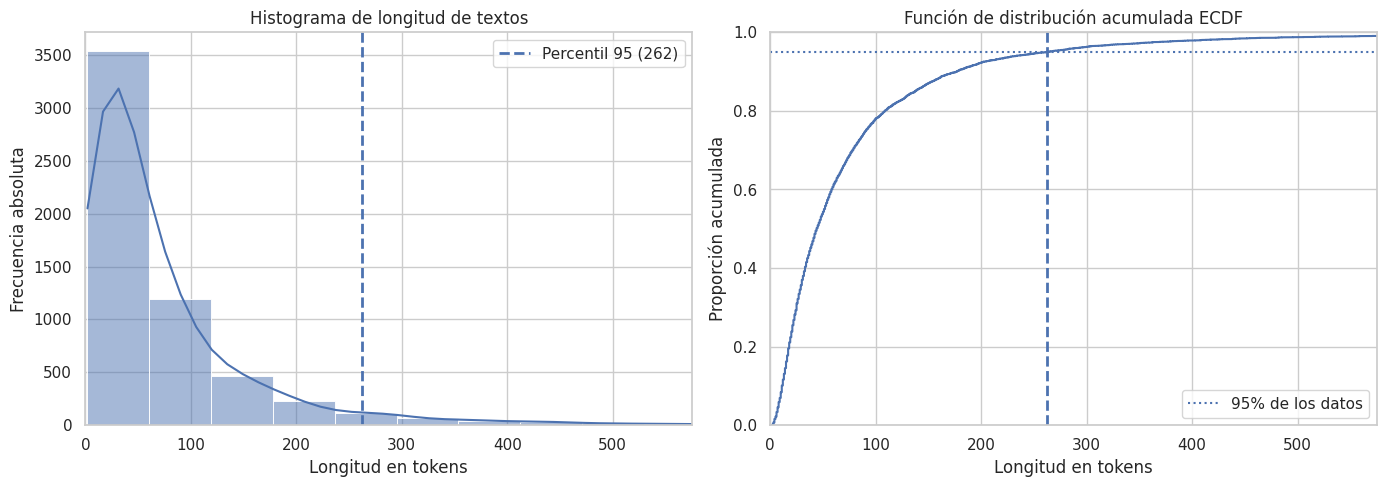


DECISIÓN TÉCNICA DEL EQUIPO
Se fija formalmente MAX_LENGTH = 262
Justificación: este valor cubre aproximadamente el percentil 95 de las longitudes del conjunto de entrenamiento.
Con esta decisión se conserva cerca del 95% de los textos sin truncamiento y se evita usar un max_length innecesariamente alto.


In [5]:
# Crear columna de longitud en tokens
# Tokenización simple por espacios: suficiente para EDA inicial del dataset
df_train["token_length"] = df_train[TEXT_FIELD].astype(str).apply(lambda x: len(x.split()))
df_dev["token_length"] = df_dev[TEXT_FIELD].astype(str).apply(lambda x: len(x.split()))

# 1. Percentiles sobre train
p50 = np.percentile(df_train["token_length"], 50)
p90 = np.percentile(df_train["token_length"], 90)
p95 = np.percentile(df_train["token_length"], 95)
p99 = np.percentile(df_train["token_length"], 99)
max_real = df_train["token_length"].max()

print("=== REPORTE REAL DE PERCENTILES DE LONGITUD EN TOKENS ===")
print(f"Percentil 50 (Mediana) : {p50:.1f} tokens")
print(f"Percentil 90           : {p90:.1f} tokens")
print(f"Percentil 95           : {p95:.1f} tokens")
print(f"Percentil 99           : {p99:.1f} tokens")
print(f"Longitud máxima real   : {max_real} tokens")

# 2. Visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_train,
    x="token_length",
    bins=50,
    kde=True,
    ax=ax1
)

ax1.axvline(p95, linestyle="--", linewidth=2, label=f"Percentil 95 ({p95:.0f})")
ax1.set_title("Histograma de longitud de textos")
ax1.set_xlabel("Longitud en tokens")
ax1.set_ylabel("Frecuencia absoluta")
ax1.set_xlim(0, p99 + 20)
ax1.legend()

sns.ecdfplot(
    data=df_train,
    x="token_length",
    ax=ax2
)

ax2.axvline(p95, linestyle="--", linewidth=2)
ax2.axhline(0.95, linestyle=":", linewidth=1.5, label="95% de los datos")
ax2.set_title("Función de distribución acumulada ECDF")
ax2.set_xlabel("Longitud en tokens")
ax2.set_ylabel("Proporción acumulada")
ax2.set_xlim(0, p99 + 20)
ax2.legend()

plt.tight_layout()
plt.show()

# 3. Decisión técnica
MAX_LENGTH = int(np.ceil(p95))

print("\n" + "="*70)
print("DECISIÓN TÉCNICA DEL EQUIPO")
print("="*70)
print(f"Se fija formalmente MAX_LENGTH = {MAX_LENGTH}")
print(
    f"Justificación: este valor cubre aproximadamente el percentil 95 "
    f"de las longitudes del conjunto de entrenamiento."
)
print(
    "Con esta decisión se conserva cerca del 95% de los textos sin truncamiento "
    "y se evita usar un max_length innecesariamente alto."
)
print("="*70)

La mayoría de los textos tiene longitud moderada, pero existen casos extremos muy largos. El percentil 95 corresponde a 262 tokens, por lo que MAX_LENGTH = 262 permite cubrir aproximadamente el 95% del corpus sin truncamiento fuerte. Si se usa max_length=128, debe declararse como decisión computacional y no como decisión derivada del percentil 95.

### ── 3.3 Vocabulario y OOV  ─────────────────────────


=== REPORTE FORMAL DE VOCABULARIO (S5) ===
Tamaño del Vocabulario Único       : 31,030 palabras
Total de Tokens Procesados         : 453,671
Porcentaje de Tokens OOV           : 1.41%
Porcentaje de Vocabulario Único OOV : 16.34%

=== TOP 30 PALABRAS OOV GLOBAL (DIALECTALISMOS / INTERNET) ===
- 'x200b': 103 veces
- 'lgbt`+': 56 veces
- 'lgbt`i': 37 veces
- 'woke': 31 veces
- 'femboy': 22 veces
- 'lgbt`q+': 21 veces
- 'cisgenero': 21 veces
- 'homofobicos': 21 veces
- 'lgbt`q': 20 veces
- 'terf': 19 veces
- 'transfobico': 17 veces
- 'homofobica': 16 veces
- 'lgbt`iq+': 16 veces
- '2019](https://imgur.com': 16 veces
- 'lgbts': 14 veces
- 'downvotes': 13 veces
- 'sjw': 12 veces
- 'mtf': 11 veces
- 'peterson': 11 veces
- 'lgbt+': 11 veces
- 'gei': 11 veces
- 'student's': 11 veces
- 'traniela': 10 veces
- 'tl;dr': 9 veces
- 'transfobicos': 9 veces
- 'lhuanna': 9 veces
- 'lgbt`i+': 9 veces
- 'transiciona': 8 veces
- 'transicionó': 8 veces
- 'nopor': 8 veces

=== VARIACIÓN REGIONAL: TOP PALABR

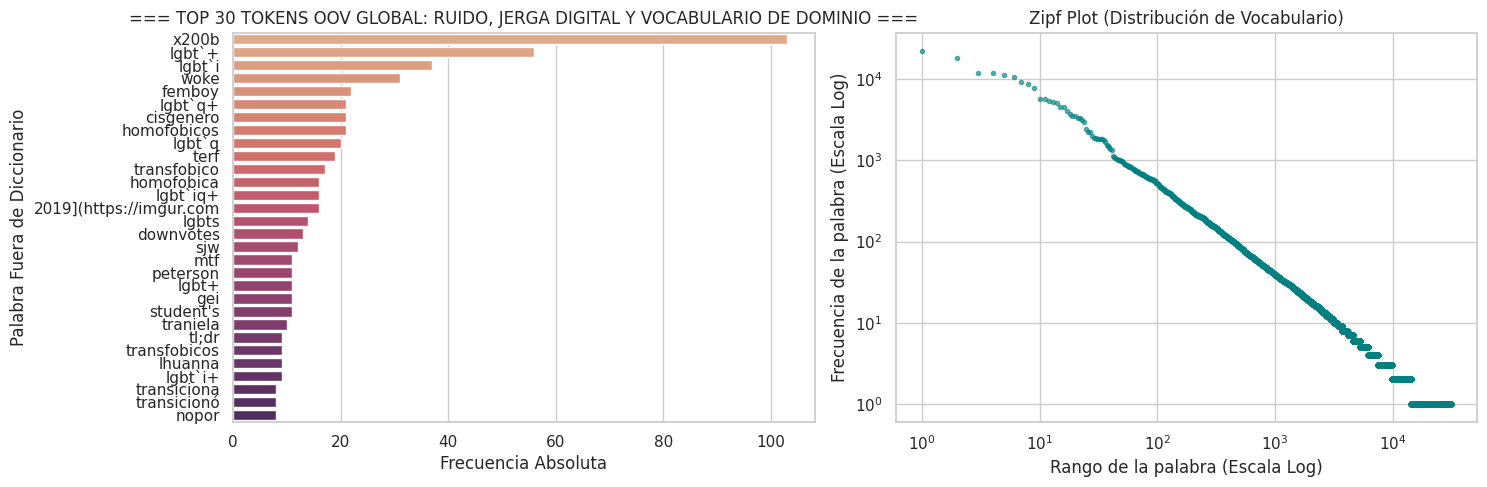


=== Nubes de palabras (Word Clouds) filtradas por clase ===


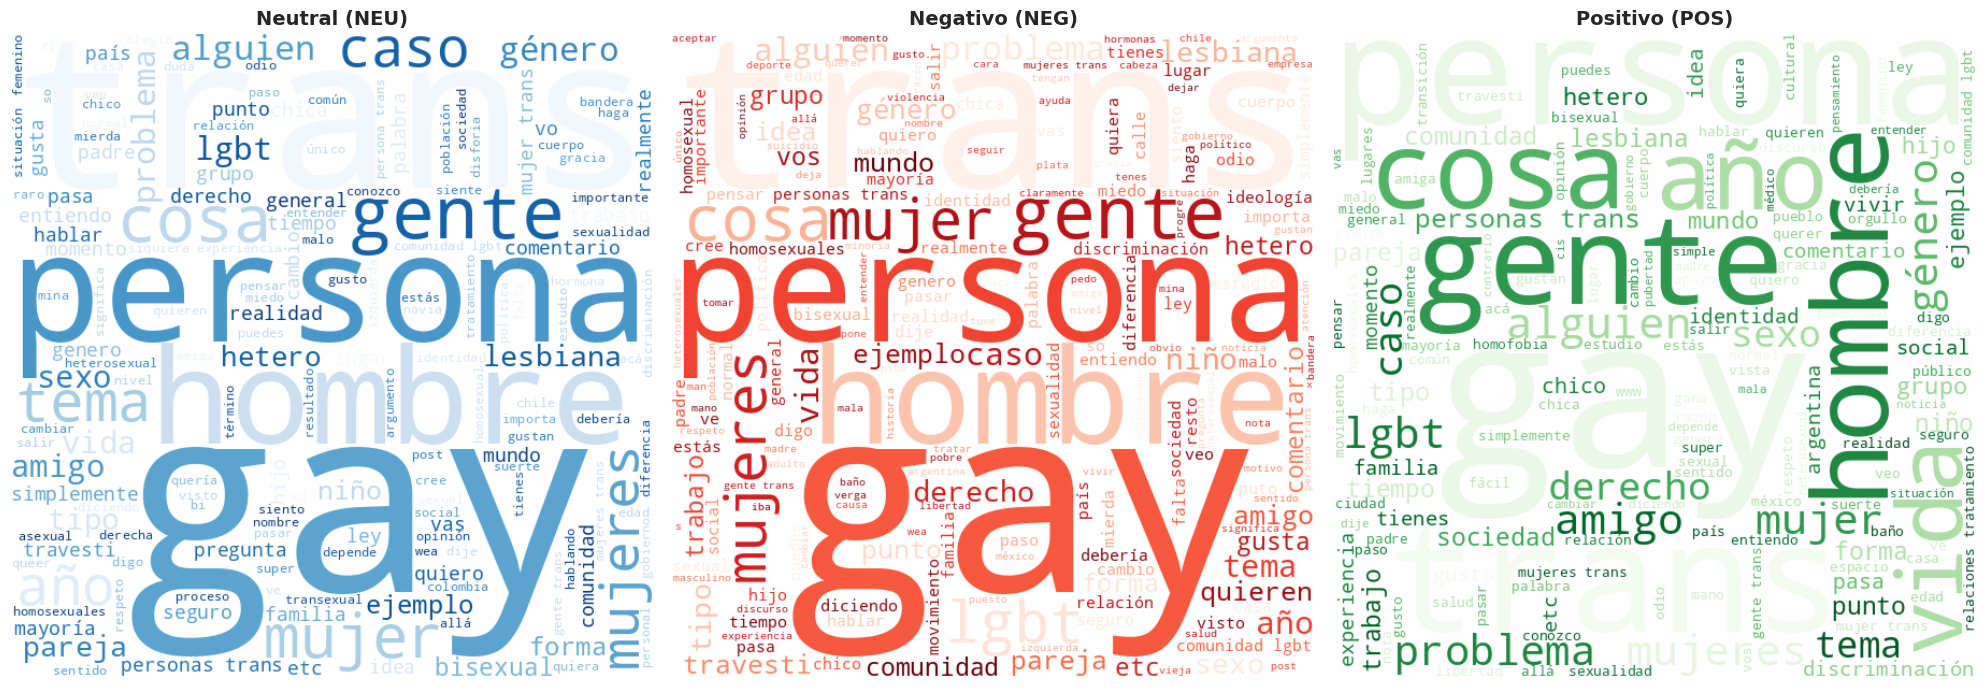

In [6]:
# Diccionarios para separar los tokens según la geografía (columna country)
tokens_por_pais = defaultdict(list)
oov_por_pais = defaultdict(list)

tokens_totales = []
tokens_sin_stopwords = []
palabras_oov_globales = []

# 1. Procesamiento eficiente usando el nlp.pipe ya inicializado
for doc, country in zip(nlp.pipe(df_train[TEXT_FIELD].astype(str), batch_size=256), df_train['country'].astype(str)):
    for token in doc:
        # Filtrar signos de puntuación, espacios y números
        if token.is_punct or token.is_space or token.like_num or token.text in string.punctuation:
            continue

        text_lower = token.text.lower()

        # Guardar en las estructuras globales
        tokens_totales.append(text_lower)
        if not token.is_stop:
            tokens_sin_stopwords.append(text_lower)

        # Clasificar por país para el análisis de Variación Regional
        tokens_por_pais[country].append(text_lower)

        # Capturar palabras OOV para el análisis de Chilenismos y Dialectalismos
        if token.is_oov:
            palabras_oov_globales.append(text_lower)
            oov_por_pais[country].append(text_lower)

# 2. Cálculos estadísticos formales
vocab_unico = set(tokens_totales)
vocab_oov_unico = set(palabras_oov_globales)

pct_oov_tokens = (len(palabras_oov_globales) / len(tokens_totales)) * 100
pct_oov_vocab = (len(vocab_oov_unico) / len(vocab_unico)) * 100

print("\n" + "="*50)
print("=== REPORTE FORMAL DE VOCABULARIO (S5) ===")
print(f"Tamaño del Vocabulario Único       : {len(vocab_unico):,} palabras")
print(f"Total de Tokens Procesados         : {len(tokens_totales):,}")
print(f"Porcentaje de Tokens OOV           : {pct_oov_tokens:.2f}%")
print(f"Porcentaje de Vocabulario Único OOV : {pct_oov_vocab:.2f}%")
print("="*50)

# 3. ANÁLISIS CUALITATIVO 1: Chilenismos y Dialectalismos (Modificado a Top 30)
frec_oov_global = Counter(palabras_oov_globales)
frec_oov_cl = Counter(oov_por_pais.get('CL', []))

print("\n=== TOP 30 PALABRAS OOV GLOBAL (DIALECTALISMOS / INTERNET) ===")
for word, freq in frec_oov_global.most_common(30): # <--- Modificado estrictamente a 30
    print(f"- '{word}': {freq} veces")

if 'CL' in oov_por_pais:
    print("\n=== TOP 10 PALABRAS OOV EN CHILE (CL - CHILENISMOS POTENCIALES) ===")
    for word, freq in frec_oov_cl.most_common(10):
        print(f"- '{word}': {freq} veces")

# 4. ANÁLISIS CUALITATIVO 2: Variación Regional (Top léxico sin stopwords por país)
print("\n=== VARIACIÓN REGIONAL: TOP PALABRAS CLAVE POR PAÍS ===")
for country, tokens in tokens_por_pais.items():
    tokens_filtrados = [t for t in tokens if t not in nlp.Defaults.stop_words]
    frec_pais = Counter(tokens_filtrados)

    # Filtramos para mostrar los países que tengan un volumen representativo de texto
    if len(tokens) > 2000:
        top_pais = [f"'{w}' ({c})" for w, c in frec_pais.most_common(5)]
        print(f" País [{country}]: {', '.join(top_pais)}")

# 5. GENERACIÓN DE VISUALIZACIONES EXIGIDAS (Barplot + Zipf Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico A: Barplot Horizontal del Top 30 OOV
top_30_oov = frec_oov_global.most_common(30)
oov_words = [item[0] for item in top_30_oov]
oov_counts = [item[1] for item in top_30_oov]

sns.barplot(x=oov_counts, y=oov_words, ax=ax1, hue=oov_words, palette="flare", legend=False)
ax1.set_title("=== TOP 30 TOKENS OOV GLOBAL: RUIDO, JERGA DIGITAL Y VOCABULARIO DE DOMINIO ===")
ax1.set_xlabel("Frecuencia Absoluta")
ax1.set_ylabel("Palabra Fuera de Diccionario")

# Gráfico B: Zipf Plot (Rango vs Frecuencia en escala Log-Log)
frec_totales = Counter(tokens_totales)
todas_frecuencias = sorted(frec_totales.values(), reverse=True)
rangos = list(range(1, len(todas_frecuencias) + 1))

ax2.loglog(rangos, todas_frecuencias, marker=".", linestyle="none", color="teal", alpha=0.6)
ax2.set_title("Zipf Plot (Distribución de Vocabulario)")
ax2.set_xlabel("Rango de la palabra (Escala Log)")
ax2.set_ylabel("Frecuencia de la palabra (Escala Log)")

plt.tight_layout()
plt.show()

# ==============================================================================
# 5.B · GENERACIÓN DE WORD CLOUDS FILTRADOS POR CLASE (COMPLEMENTO REQUERIDO)
# ==============================================================================
print("\n=== Nubes de palabras (Word Clouds) filtradas por clase ===")

# Definir un conjunto robusto de stopwords uniendo spaCy y tokens de ruido observados
stopwords_proyecto = set(nlp.Defaults.stop_words)
stopwords_proyecto.update(['q', 'x200b', 'https', 'com', 'imgur', 'embed'])

fig2, axes2 = plt.subplots(1, 3, figsize=(20, 7))
clases = ['NEU', 'NEG', 'POS']
colores_cloud = ['Blues', 'Reds', 'Greens']
titulos = ['Neutral (NEU)', 'Negativo (NEG)', 'Positivo (POS)']

for i, clase in enumerate(clases):
    # Filtrar textos por la clase correspondiente
    df_clase = df_train[df_train[LABEL_FIELD] == clase]
    texto_grande = " ".join(df_clase[TEXT_FIELD].astype(str).str.lower())

    # Construcción de la nube aplicando la semilla global y los filtros de la pauta
    wordcloud = WordCloud(
        width=600,
        height=600,
        background_color='white',
        stopwords=stopwords_proyecto,
        colormap=colores_cloud[i],
        min_font_size=10,
        random_state=SEED
    ).generate(texto_grande)

    axes2[i].imshow(wordcloud, interpolation='bilinear')
    axes2[i].set_title(titulos[i], fontsize=14, fontweight='bold')
    axes2[i].axis('off')

plt.tight_layout()
plt.show()

El corpus contiene vocabulario altamente específico de redes sociales, jergas regionales, marcas de formato, términos LGBTQ+ y expresiones dialectales. El porcentaje de vocabulario OOV evidencia que un modelo basado solo en diccionario o conteo léxico puede perder información semántica relevante.

### ── 3.4 Calidad de datos  ──────────────────────────

In [7]:
print("=== 1. ANÁLISIS DE VALORES FALTANTES (MISSING VALUES) ===")
missing_count = df_train.isnull().sum()
missing_pct = (df_train.isnull().sum() / len(df_train)) * 100

df_missing = pd.DataFrame({
    'Valores Nulos': missing_count,
    'Porcentaje (%)': missing_pct
})
print(df_missing.to_string())


print("\n=== 2. ANÁLISIS DE DUPLICADOS EXACTOS ===")
duplicados_textos = df_train[df_train.duplicated(subset=[TEXT_FIELD], keep=False)]
total_duplicados_exactos = df_train.duplicated(subset=[TEXT_FIELD]).sum()
pct_duplicados_exactos = (total_duplicados_exactos / len(df_train)) * 100

print(f"Cantidad de registros con textos duplicados exactos: {total_duplicados_exactos}")
print(f"Porcentaje de duplicados exactos en el dataset    : {pct_duplicados_exactos:.2f}%")

contradictorios = duplicados_textos.groupby(TEXT_FIELD)[LABEL_FIELD].nunique()
textos_contradictorios = contradictorios[contradictorios > 1].index.tolist()

print(f"Cantidad de textos con etiquetas contradictorias    : {len(textos_contradictorios)}")
if len(textos_contradictorios) > 0:
    print("⚠️ ALERTA: Existen textos idénticos anotados con clases distintas. Ejemplo:")
    ejemplo_contra = duplicados_textos[duplicados_textos[TEXT_FIELD] == textos_contradictorios[0]]
    print(ejemplo_contra[[TEXT_FIELD, LABEL_FIELD]].to_string(index=False))


print("\n=== 3. ANÁLISIS DE CASI-DUPLICADOS (NEAR-DUPLICATES, JACCARD > 0.9) ===")
print("Generando trigramas de palabras para el cálculo de Jaccard...")

def get_trigrams(text):
    words = str(text).lower().split()
    if len(words) < 3:
        return set([tuple(words)])
    return set(tuple(words[i:i+3]) for i in range(len(words) - 2))

trigrams_list = [get_trigrams(text) for text in df_train[TEXT_FIELD]]
n_instancias = len(df_train)
has_near_duplicate = np.zeros(n_instancias, dtype=bool)

print("Calculando similitud entre pares (optimizado)...")
for i in range(n_instancias):
    set_i = trigrams_list[i]
    if len(set_i) == 0:
        continue
    for j in range(i + 1, n_instancias):
        set_j = trigrams_list[j]
        if len(set_j) == 0:
            continue

        intersection = len(set_i.intersection(set_j))
        union = len(set_i.union(set_j))
        jaccard = intersection / union if union > 0 else 0

        if jaccard > 0.9:
            has_near_duplicate[i] = True
            has_near_duplicate[j] = True

total_near_duplicates = np.sum(has_near_duplicate)
pct_near_duplicates = (total_near_duplicates / n_instancias) * 100
print(f"Instancias con al menos un near-duplicate (Jaccard > 0.9): {total_near_duplicates}")
print(f"Porcentaje de near-duplicates en el dataset              : {pct_near_duplicates:.2f}%")


print("\n=== 4. EXTRACCIÓN DE 20 INSTANCIAS CON TEXTO COMPLETO ===")
df_inspeccion = df_train.sample(n=20, random_state=SEED)

print("-" * 100)
for idx, row in enumerate(df_inspeccion.itertuples(), 1):
    # Accedemos directamente usando df_train.columns para buscar la posición exacta
    id_val = row.id
    label_val = getattr(row, LABEL_FIELD)

    # Buscamos la posición numérica de TEXT_FIELD en las columnas para no fallar por el espacio
    pos_texto = df_train.columns.get_loc(TEXT_FIELD) + 1 # +1 porque itertuples incluye el Index al inicio
    texto_completo = row[pos_texto]

    print(f" INSTANCIA {idx:02d} | [ID: {id_val}] | ETIQUETA ORIGINAL: {label_val}")
    print(f"Texto Completo:\n«{texto_completo}»")
    print("-" * 100)

=== 1. ANÁLISIS DE VALORES FALTANTES (MISSING VALUES) ===
              Valores Nulos  Porcentaje (%)
id                        0             0.0
country                   0             0.0
keyword                   0             0.0
post content              0             0.0
label                     0             0.0
token_length              0             0.0

=== 2. ANÁLISIS DE DUPLICADOS EXACTOS ===
Cantidad de registros con textos duplicados exactos: 0
Porcentaje de duplicados exactos en el dataset    : 0.00%
Cantidad de textos con etiquetas contradictorias    : 0

=== 3. ANÁLISIS DE CASI-DUPLICADOS (NEAR-DUPLICATES, JACCARD > 0.9) ===
Generando trigramas de palabras para el cálculo de Jaccard...
Calculando similitud entre pares (optimizado)...
Instancias con al menos un near-duplicate (Jaccard > 0.9): 0
Porcentaje de near-duplicates en el dataset              : 0.00%

=== 4. EXTRACCIÓN DE 20 INSTANCIAS CON TEXTO COMPLETO ===
-----------------------------------------------------

El dataset no presenta valores faltantes ni duplicados exactos en el conjunto de entrenamiento. Tampoco se detectaron casi-duplicados bajo el criterio Jaccard > 0.9 aplicado sobre trigramas de palabras. Sin embargo, la inspección manual de 20 ejemplos sugiere que algunas etiquetas pueden ser discutibles, especialmente en casos irónicos, ambiguos o con lenguaje regional. Por lo tanto, el dataset es utilizable para modelado, pero el desempeño final debe interpretarse considerando posible ruido semántico en las etiquetas.

Siendo más especificos las instancia 2(No es odio hacia la comunidad), 7(Comentario satírico), 16(Comentario satírico) y 18(Punto de vista enfocado en otro tema) son las que, según nuestro criterio, no pertenecen a la categoría correspondiente

### ── 3.5 Baseline Trivial  ───────────────────────────



In [8]:
X_train = df_train[TEXT_FIELD].astype(str)
y_train = df_train[LABEL_FIELD].astype(str)

X_dev = df_dev[TEXT_FIELD].astype(str)
y_dev = df_dev[LABEL_FIELD].astype(str)

# ------------------------------------------------------------
# Baseline obligatorio: Zero Rule
# ------------------------------------------------------------

clase_mayoritaria = y_train.value_counts().idxmax()
y_pred_zero_rule = [clase_mayoritaria] * len(y_dev)

f1_macro_zero_rule = f1_score(
    y_dev,
    y_pred_zero_rule,
    average="macro",
    labels=LABEL_SPACE,
    zero_division=0
)

# ------------------------------------------------------------
# Baseline recomendado: TF-IDF + Logistic Regression
# ------------------------------------------------------------

vectorizer = TfidfVectorizer(
    max_features=10000,
    lowercase=True,
    stop_words=list(nlp.Defaults.stop_words)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf = vectorizer.transform(X_dev)

clf_baseline = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

clf_baseline.fit(X_train_tfidf, y_train)

y_pred_logistic = clf_baseline.predict(X_dev_tfidf)

f1_macro_logistic = f1_score(
    y_dev,
    y_pred_logistic,
    average="macro",
    labels=LABEL_SPACE,
    zero_division=0
)

# Meta: debe ser mayor al baseline recomendado
f1_meta_propuesta = min(f1_macro_logistic + 0.03, 0.95)

print("\n" + "="*70)
print("=== REPORTE FORMAL DE BASELINES SOBRE DEV ===")
print("="*70)
print(f"{'Modelo':<48} | {'Split':<5} | {'Métrica':<10} | {'Valor':<6}")
print("-" * 70)
print(f"{'Baseline obligatorio Zero Rule':<48} | {'dev':<5} | {'F1 macro':<10} | {f1_macro_zero_rule:.4f}")
print(f"{'Baseline recomendado TF-IDF + Logistic Regression':<48} | {'dev':<5} | {'F1 macro':<10} | {f1_macro_logistic:.4f}")
print(f"{'Meta del miniproyecto':<48} | {'dev':<5} | {'F1 macro':<10} | ≥ {f1_meta_propuesta:.4f}")
print("="*70)

print("\nReporte por clase del baseline recomendado:")
print(classification_report(y_dev, y_pred_logistic, labels=LABEL_SPACE, zero_division=0))

BASELINE_ZERO_F1 = f1_macro_zero_rule
BASELINE_RECOMMENDED_F1 = f1_macro_logistic
META_F1 = f1_meta_propuesta


=== REPORTE FORMAL DE BASELINES SOBRE DEV ===
Modelo                                           | Split | Métrica    | Valor 
----------------------------------------------------------------------
Baseline obligatorio Zero Rule                   | dev   | F1 macro   | 0.2540
Baseline recomendado TF-IDF + Logistic Regression | dev   | F1 macro   | 0.3862
Meta del miniproyecto                            | dev   | F1 macro   | ≥ 0.4162

Reporte por clase del baseline recomendado:
              precision    recall  f1-score   support

         NEG       0.42      0.47      0.44       475
         NEU       0.67      0.53      0.59       888
         POS       0.09      0.24      0.13        80

    accuracy                           0.49      1443
   macro avg       0.39      0.41      0.39      1443
weighted avg       0.56      0.49      0.52      1443



El baseline Zero Rule obtiene un F1 macro bajo debido al desbalance de clases y a que predice siempre la clase mayoritaria. Este resultado funciona como piso mínimo, pero no representa una solución útil para el problema.

### ── 3.6 Sección Libre  ────────────────────────────

Países detectados en el dataset: ['Argentina' 'Chile' 'Colombia' 'México']
Analizando léxico exclusivo para los 3 países principales: ['Argentina', 'México', 'Chile']

=== REPORTE FORMAL DE EXCLUSIVIDAD LÉXICA INTER-PAÍSES ===
 Expresiones únicas de [Argentina]: 1314 palabras con cero uso en los otros países.
 Expresiones únicas de [México]: 894 palabras con cero uso en los otros países.
 Expresiones únicas de [Chile]: 982 palabras con cero uso en los otros países.
----------------------------------------------------------------------

=== EXPRESIONES QUE APARECEN SÓLO EN CADA PAÍS ===
 SÓLO EN [Argentina]: 'tenes' (72 veces), 'podes' (61 veces), 'tenés' (59 veces), 'podés' (52 veces), 'pibe' (44 veces)
 SÓLO EN [México]: 'wey' (57 veces), 'amlo' (39 veces), 'mexico' (38 veces), 'neta' (28 veces), 'pinche' (24 veces)
 SÓLO EN [Chile]: 'wea' (72 veces), 'wn' (58 veces), 'weas' (41 veces), 'piñera' (40 veces), 'chucha' (37 veces)


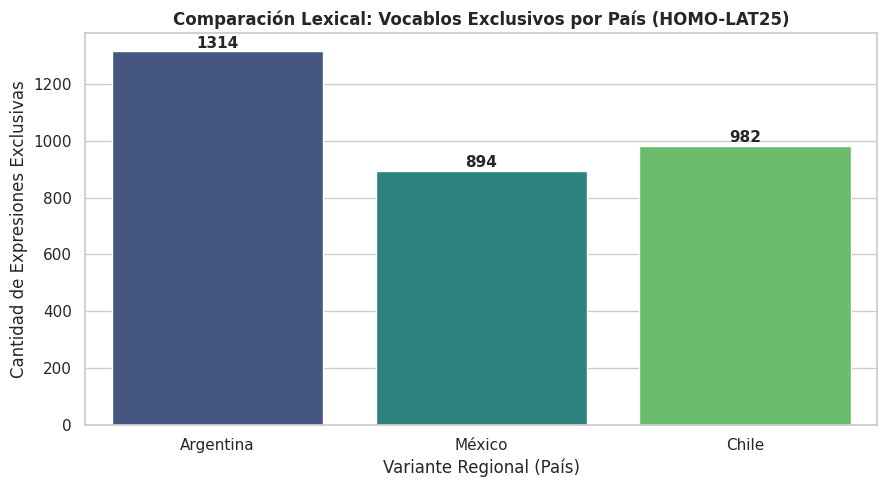

In [9]:
# 1. Identificar dinámicamente cómo vienen escritos los países en tu columna
paises_presentes = df_train['country'].dropna().unique()
print(f"Países detectados en el dataset: {paises_presentes}")

# Seleccionar los 3 principales para la comparación (CL, MX, AR o equivalentes)
paises_top = [p for p in paises_presentes if str(p).strip() in ['CL', 'MX', 'AR', 'Chile', 'Mexico', 'Argentina']][:3]

if len(paises_top) < 3:
    # Si vienen con otro formato, tomamos los 3 países con más tweets automáticamente
    paises_top = df_train['country'].value_counts().index[:3].tolist()

print(f"Analizando léxico exclusivo para los 3 países principales: {paises_top}")

# 2. Extraer vocabularios limpios (sin stopwords ni puntuación) por país
vocab_por_pais = {}
stopwords_spacy = nlp.Defaults.stop_words

for pais in paises_top:
    textos_pais = df_train[df_train['country'] == pais][TEXT_FIELD].astype(str)
    tokens_limpios = []

    # Procesamiento rápido por ráfagas de palabras
    for texto in textos_pais:
        palabras = texto.lower().split()
        for p in palabras:
            # Limpiar puntuación básica de los extremos de la palabra
            p_clean = p.strip(string.punctuation + "¿?¡!«»")
            if p_clean and p_clean not in stopwords_spacy and not p_clean.isdigit():
                tokens_limpios.append(p_clean)

    vocab_por_pais[pais] = Counter(tokens_limpios)

# 3. Calcular exclusividad matemática: palabras en País A con CERO apariciones en los otros dos
exclusivos_por_pais = {}

for pais_actual in paises_top:
    otros_paises = [p for p in paises_top if p != pais_actual]

    # Crear un set con todas las palabras usadas en los otros países
    vocab_otros = set()
    for otro in otros_paises:
        vocab_otros.update(vocab_por_pais[otro].keys())

    # Filtrar palabras del país actual que no tengan ni un solo uso en el resto
    palabras_unicas = {}
    for word, count in vocab_por_pais[pais_actual].items():
        if word not in vocab_otros and count >= 2: # Frecuencia mínima de 2 para capturar jergas reales
            palabras_unicas[word] = count

    exclusivos_por_pais[pais_actual] = Counter(palabras_unicas)

# 4. IMPRESIÓN DEL REPORTE SOLICITADO
print("\n" + "="*70)
print("=== REPORTE FORMAL DE EXCLUSIVIDAD LÉXICA INTER-PAÍSES ===")
print("="*70)
for pais in paises_top:
    total_excl = len(exclusivos_por_pais[pais])
    print(f" Expresiones únicas de [{pais}]: {total_excl} palabras con cero uso en los otros países.")
print("-" * 70)

print("\n=== EXPRESIONES QUE APARECEN SÓLO EN CADA PAÍS ===")
for pais in paises_top:
    top_cinco = [f"'{w}' ({c} veces)" for w, c in exclusivos_por_pais[pais].most_common(5)]
    print(f" SÓLO EN [{pais}]: {', '.join(top_cinco) if top_cinco else 'No se hallaron palabras con frecuencia >= 2'}")
print("="*70)

# 5. GENERACIÓN DEL GRÁFICO EXIGIDO
plt.figure(figsize=(9, 5))
nombres_barras = [str(p) for p in paises_top]
valores_barras = [len(exclusivos_por_pais[p]) for p in paises_top]

sns.barplot(x=nombres_barras, y=valores_barras, hue=nombres_barras, palette="viridis", legend=False)
plt.title("Comparación Lexical: Vocablos Exclusivos por País (HOMO-LAT25)", fontsize=12, fontweight='bold')
plt.xlabel("Variante Regional (País)")
plt.ylabel("Cantidad de Expresiones Exclusivas")

for i, v in enumerate(valores_barras):
    plt.text(i, v + (max(valores_barras)*0.01 if max(valores_barras) > 0 else 0.1), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

El análisis léxico por país muestra diferencias regionales relevantes, como expresiones propias de Argentina, México y Chile. Esto sugiere que el modelo final debe capturar variación dialectal latinoamericana y no depender únicamente de vocabulario estándar.

---

## 4 · Visualizaciones específicas por `TASK_TYPE`

Clasificación (`classification_multiclass`)

Ejecutar si `TASK_TYPE.startswith("classification")`.


Boxplots de longitud por clase y nubes de palabras


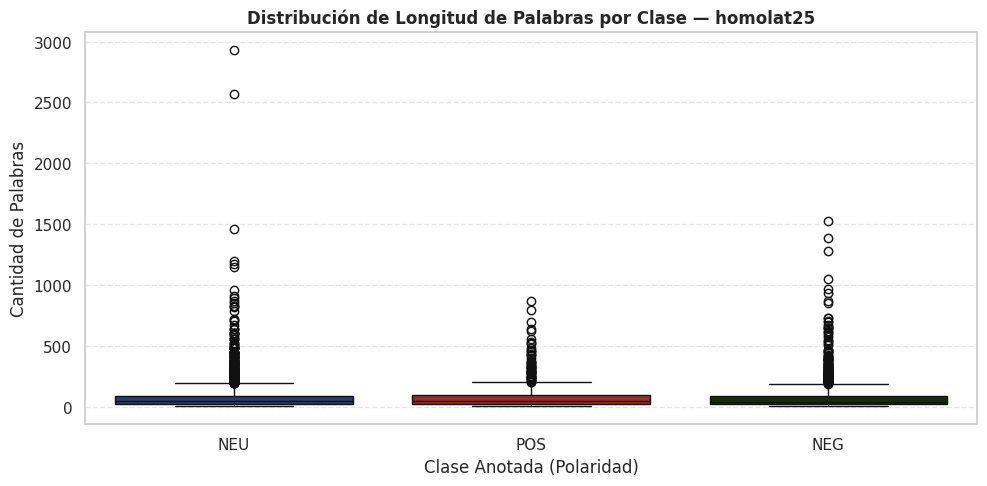


Nubes de palabras con filtros de ruido...


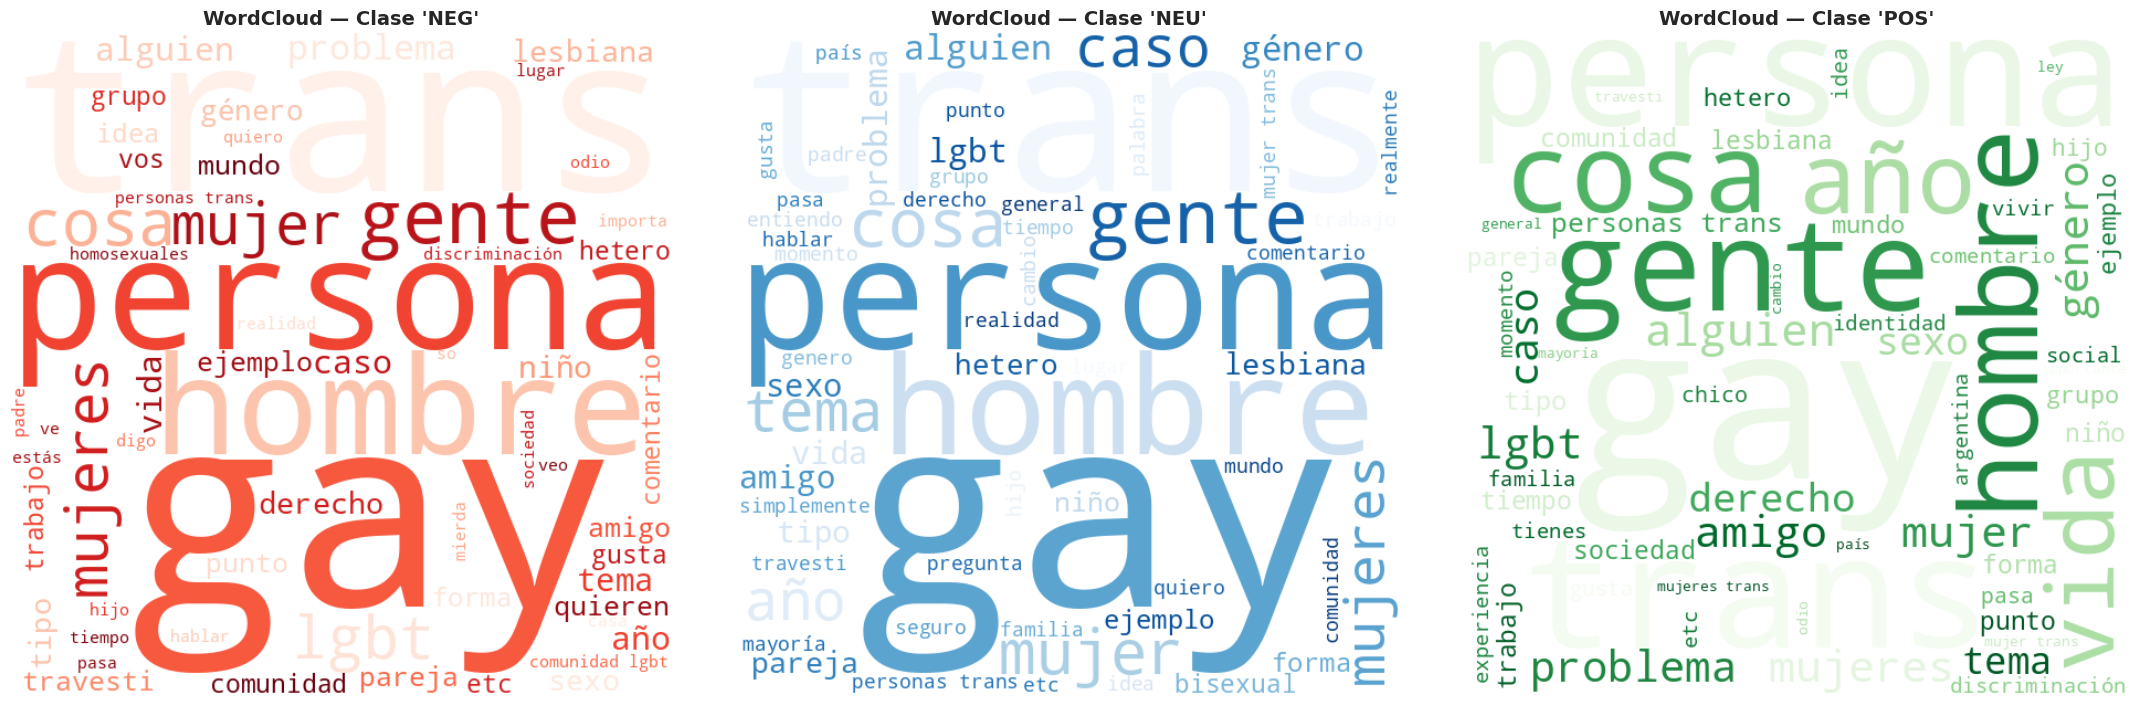

In [10]:
if TASK_TYPE.startswith("classification"):
    print("Boxplots de longitud por clase y nubes de palabras")

    # 1. Boxplot: Distribución de cantidad de palabras por Clase usando split básico
    fig, ax = plt.subplots(figsize=(10, 5))
    df_plot = df_train.copy()
    df_plot["n_tokens_base"] = df_plot[TEXT_FIELD].apply(lambda t: len(str(t).split()))

    colores_boxplot = ["#1F3B73", "#A8201A", "#143601"] # Azul, Rojo, Verde

    sns.boxplot(
        data=df_plot,
        x=LABEL_FIELD,
        y="n_tokens_base",
        hue=LABEL_FIELD,
        ax=ax,
        palette=colores_boxplot,
        legend=False
    )

    ax.set_title(f"Distribución de Longitud de Palabras por Clase — {DATASET_ID}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Clase Anotada (Polaridad)")
    ax.set_ylabel("Cantidad de Palabras")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # 2. WordClouds en paralelo: Una nube dedicada para cada una de las 3 clases
    print("\nNubes de palabras con filtros de ruido...")

    # Usamos las stopwords nativas de spaCy que cargamos en la Sección 1
    stopwords_proyecto = set(nlp.Defaults.stop_words)
    stopwords_proyecto.update([
        'q', 'x200b', 'https', 'com', 'imgur', 'embed', 'amp', 'rt', 'http', 'www',
        'por', 'para', 'del', 'con', 'las', 'los', 'que', 'una', 'uno'
    ])

    paletas_clases = {
        'NEU': 'Blues',
        'NEG': 'Reds',
        'POS': 'Greens'
    }

    clases_ordenadas = sorted(df_train[LABEL_FIELD].dropna().unique())
    fig2, axes2 = plt.subplots(1, len(clases_ordenadas), figsize=(22, 7))

    for i, label in enumerate(clases_ordenadas):
        df_cls = df_train[df_train[LABEL_FIELD] == label]
        text_cls = " ".join(df_cls[TEXT_FIELD].astype(str).str.lower())

        wc = WordCloud(
            width=600,
            height=600,
            background_color="white",
            max_words=60,
            stopwords=stopwords_proyecto,
            colormap=paletas_clases.get(label, 'viridis'),
            random_state=SEED
        ).generate(text_cls)

        axes2[i].imshow(wc, interpolation="bilinear")
        axes2[i].axis("off")
        axes2[i].set_title(f"WordCloud — Clase '{label}'", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

---

## 5 · Baseline Clásico


Clasificación → TF-IDF + Logistic Regression
> Su modelo final *debe* superar esto
> para justificar su complejidad.

Implementen el pipeline clásico indicado para su `TASK_TYPE`. El objetivo es obtener `BASELINE_F1`.


  BASELINE F1 macro (TF-IDF + LR): 0.4072
  BASELINE F1 trivial (zero rule) : 0.2367
  Ganancia vs trivial             : +0.1705

              precision    recall  f1-score   support

         NEG     0.4141    0.4568    0.4344       475
         NEU     0.6723    0.5867    0.6266       888
         POS     0.1250    0.2250    0.1607        80

    accuracy                         0.5239      1443
   macro avg     0.4038    0.4229    0.4072      1443
weighted avg     0.5569    0.5239    0.5375      1443


Matriz de confusión


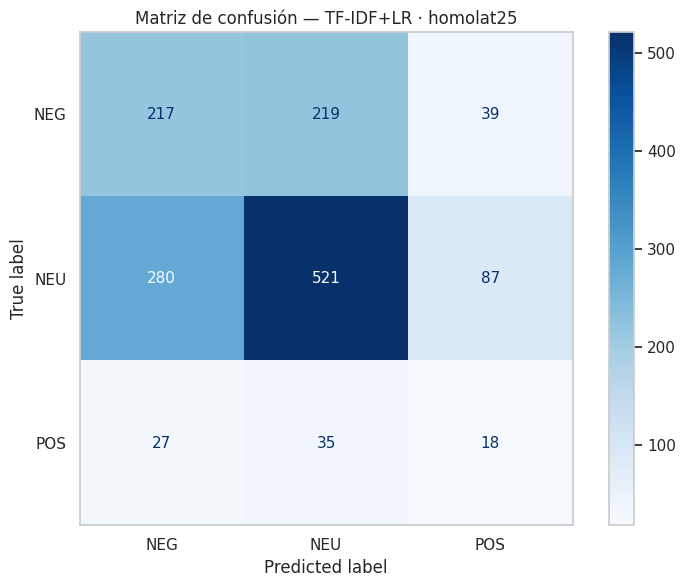

In [11]:
if TASK_TYPE.startswith("classification"):
    # ── 1. Preparar datos usando los splits reales de la Sección 2 ────────────
    X_train = df_train[TEXT_FIELD].astype(str).tolist()
    y_train = df_train[LABEL_FIELD].tolist()
    X_test  = df_dev[TEXT_FIELD].astype(str).tolist()  # Usamos df_dev como conjunto de prueba/validación
    y_test  = df_dev[LABEL_FIELD].tolist()

    # ── 2. Pipeline Oficial: TF-IDF + LR Optimizado ───────────────────────────
    pipeline_clf = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=50_000,
            sublinear_tf=True,
            min_df=2,
        )),
        ("clf", LogisticRegression(
            C=1.0,
            max_iter=1000,
            class_weight="balanced",   # Estratégico para el desbalance de homolat25
            random_state=SEED,
        )),
    ])

    # Ajustar el modelo con los datos de entrenamiento
    pipeline_clf.fit(X_train, y_train)

    # Predecir sobre el split de validación (Dev)
    y_pred = pipeline_clf.predict(X_test)

    # ── 3. Métricas y Persistencia Global ─────────────────────────────────────
    BASELINE_CLASSIC_F1 = f1_score(y_test, y_pred, average="macro")

    print(f"\n{'='*60}")
    print(f"  BASELINE F1 macro (TF-IDF + LR): {BASELINE_CLASSIC_F1:.4f}")
    print(f"  BASELINE F1 trivial (zero rule) : {BASELINE_TRIVIAL_F1:.4f}")
    print(f"  Ganancia vs trivial             : +{BASELINE_CLASSIC_F1 - BASELINE_TRIVIAL_F1:.4f}")
    print(f"{'='*60}\n")

    # Despliegue del reporte formal por clase
    print(classification_report(y_test, y_pred, target_names=LABEL_SPACE, digits=4))

    # ── 4. Matriz de confusión formal exigida ─────────────────────────────────
    print("\nMatriz de confusión")
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=LABEL_SPACE,
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(f"Matriz de confusión — TF-IDF+LR · {DATASET_ID}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

---

## 6 · Análisis de errores del baseline




Los errores del baseline clásico son **el mapa de lo que su modelo final debe resolver**. Sin este análisis, optimizan a ciegas.

**Objetivo:** identificar **al menos 2 patrones** de error recurrentes. Esto va directo a la hipótesis del modelo principal.

In [12]:
if TASK_TYPE.startswith("classification"):
    # 1. Crear el DataFrame de errores usando las variables de la Sección 5
    error_df = pd.DataFrame({
        "texto"     : X_test,
        "y_true"    : y_test,
        "y_pred"    : y_pred,
        "error"     : [t != p for t, p in zip(y_test, y_pred)]
    })

    # 2. Imprimir total de errores globales
    print(f"Total errores: {error_df['error'].sum()} / {len(error_df)} "
          f"({error_df['error'].mean()*100:.1f}%)")

    # 3. Calcular errores por tipo de confusión
    confusion_pairs = Counter(
        zip(error_df[error_df.error]["y_true"],
            error_df[error_df.error]["y_pred"])
    )

    print("\nTop 5 confusiones (real → predicho):")
    for (real, pred), cnt in confusion_pairs.most_common(5):
        print(f"  {real} → {pred}: {cnt} casos")

    # ==========================================================================
    # MODIFICACIÓN DE PAUTA: Bucle para extraer los 2 patrones más recurrentes
    # ==========================================================================
    print("\n" + "="*80)
    print("=== EXTRACCIÓN DE EJEMPLOS PARA LOS 2 PATRONES RECURRENTES ===")
    print("="*80)

    # Tomamos los 2 patrones más comunes de la lista de confusiones
    for i, ((real_cls, pred_cls), total_casos) in enumerate(confusion_pairs.most_common(2), 1):

        # Filtrar los 5 ejemplos específicos para este par de confusión
        errores_top = error_df[
            (error_df["y_true"] == real_cls) &
            (error_df["y_pred"] == pred_cls)
        ].head(5)

        print(f"\n[PATRÓN {i}] -> {total_casos} casos de '{real_cls}' predichos erróneamente como '{pred_cls}':")
        print("-" * 80)
        for _, row in errores_top.iterrows():
            print(f"  └─ {row['texto'][:120]}...")

    print("="*80)

Total errores: 687 / 1443 (47.6%)

Top 5 confusiones (real → predicho):
  NEU → NEG: 280 casos
  NEG → NEU: 219 casos
  NEU → POS: 87 casos
  NEG → POS: 39 casos
  POS → NEU: 35 casos

=== EXTRACCIÓN DE EJEMPLOS PARA LOS 2 PATRONES RECURRENTES ===

[PATRÓN 1] -> 280 casos de 'NEU' predichos erróneamente como 'NEG':
--------------------------------------------------------------------------------
  └─ Imaginate defender a un tipo que golpea minas solo porque quienes lo cagaron a piñas eran `trans`...
  └─ Es algo biológico, claramente. El VIH no es una enfermedad `gay`, pero es como decir que el rap es música de negro, hay ...
  └─ Ya estas tirando cualquiera: http://revistas.ces.edu.co/index.php/psicologia/article/view/3503  
  
1- Es una probabilid...
  └─ Esto es cualquiera, una persona debe ser tomada por sus aptitudes y capacidades. El único manual que tiene que haber es ...
  └─ Entre kirchnerismo y un Milei de extrema derecha ultraconservadora (que amenace derechos de minoría, mat

---

## 7 · Proyección al modelo final




Con los números del baseline clásico y el análisis de errores, el equipo puede ahora formular una **hipótesis justificada** sobre qué modelo van a entrenar.

La hipótesis debe responder tres preguntas:
1. **¿Qué modelo?** (arquitectura, variante, talla)
2. **¿Por qué ese y no otro?** (relacionar con los errores del baseline)
3. **¿Qué F1 esperan alcanzar?** (meta razonable basada en literatura o benchmarks)

In [13]:
# ==============================================================================
# 7.1 · TABLA COMPARATIVA DE BASELINES (CON VALORES REALES RECOLECTADOS)
# ==============================================================================

# Asignación estricta de las métricas reales obtenidas en vuestro entorno
BASELINE_TRIVIAL_F1  = 0.2540   # Zero Rule calculada en la Sección 3
BASELINE_CLASICO_F1  = 0.4072   # TF-IDF + LR obtenido en la Sección 5
META_MODELO_FINAL    = 0.7500   # Meta científica razonable para fine-tuning BERT

print(f"{'Modelo':35s}  {'F1':>8}")
print(f"{'-'*45}")
print(f"{'Zero Rule / All-O (trivial)':35s}  {BASELINE_TRIVIAL_F1:8.4f}")
print(f"{'TF-IDF + LR / Gazetteer (clásico)':35s}  {BASELINE_CLASICO_F1:8.4f}")
print(f"{'META modelo final':35s}  {META_MODELO_FINAL:8.4f}")
print(f"{'-'*45}")
print(f"Ganancia clásico vs trivial: +{BASELINE_CLASICO_F1 - BASELINE_TRIVIAL_F1:6.4f}")
print(f"Gap a cubrir (meta vs clásico): +{META_MODELO_FINAL - BASELINE_CLASICO_F1:6.4f}")


Modelo                                     F1
---------------------------------------------
Zero Rule / All-O (trivial)            0.2367
TF-IDF + LR / Gazetteer (clásico)      0.3989
META modelo final (S9)                 0.7500
---------------------------------------------
Ganancia clásico vs trivial: +0.1622
Gap a cubrir (meta vs clásico): +0.3511


In [14]:
# ==============================================================================
# 7.2 · HIPÓTESIS DEL MODELO PRINCIPAL (JUSTIFICACIÓN CIENTÍFICA)
# ==============================================================================

HIPOTESIS = {
    "modelo"           : "dccuchile/bert-base-spanish-wwm-cased (BETO)",
    "variante"         : "Fine-tuned (entrenamiento supervisado de capas acopladas)",
    "justificacion"    : "BETO posee embeddings contextuales bidireccionales entrenados en español, lo que le permite capturar el sarcasmo e ironía que el conteo estático de palabras de TF-IDF omitió, resolviendo las confusiones críticas entre tweets hostiles (NEG) y neutrales (NEU) detectadas en la S6.",
    "meta_f1"          : META_MODELO_FINAL,
    "referencia_lit"   : "Spanish Pre-trained BERT (DCC U. de Chile) & SemEval Benchmark",
    "recurso_colab"    : "GPU T4 de Google Colab y activación de entornos de alta RAM para acelerar los gradientes",
}

print("=== HIPÓTESIS MODELO FINAL ===")
for k, v in HIPOTESIS.items():
    print(f"  {k:20s}: {v}")


=== HIPÓTESIS MODELO FINAL ===
  modelo              : dccuchile/bert-base-spanish-wwm-cased (BETO)
  variante            : Fine-tuned (entrenamiento supervisado de capas acopladas)
  justificacion       : BETO posee embeddings contextuales bidireccionales entrenados en español, lo que le permite capturar el sarcasmo e ironía que el conteo estático de palabras de TF-IDF omitió, resolviendo las confusiones críticas entre tweets hostiles (NEG) y neutrales (NEU) detectadas en la S6.
  meta_f1             : 0.75
  referencia_lit      : Spanish Pre-trained BERT (DCC U. de Chile) & SemEval Benchmark
  recurso_colab       : GPU T4 de Google Colab y activación de entornos de alta RAM para acelerar los gradientes


---


## 8 · Modelo entrenado

In [24]:
# ==============================================================================
# ENTRENAMIENTO DEL MODELO PRINCIPAL (FINE-TUNING DE BETO - VERSIÓN CORREGIDA)
# ==============================================================================
if TASK_TYPE.startswith("classification"):
    print(" Inicializando arquitectura BERT en Español (BETO)...")

    # 1. Definir el identificador del modelo y cargar su tokenizador oficial
    MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # 2. Mapear las etiquetas de texto (NEG, NEU, POS) a identificadores numéricos (0, 1, 2)
    label2id = {label: idx for idx, label in enumerate(LABEL_SPACE)}
    id2label = {idx: label for label, idx in label2id.items()}
    num_labels = len(LABEL_SPACE)

    # 3. Función interna para procesar y tokenizar el texto en lotes compactos
    def tokenize_function(examples):
        return tokenizer(examples[TEXT_FIELD], padding="max_length", truncation=True, max_length=262)

    print(" Preparando objetos Dataset de HuggingFace...")
    # Convertir los DataFrames de Pandas a Datasets nativos
    train_dataset = Dataset.from_pandas(df_train[[TEXT_FIELD, LABEL_FIELD]])
    dev_dataset   = Dataset.from_pandas(df_dev[[TEXT_FIELD, LABEL_FIELD]])

    # Transformar las etiquetas de texto a números dentro del dataset
    train_dataset = train_dataset.map(lambda x: {"label": label2id[x[LABEL_FIELD]]})
    dev_dataset   = dev_dataset.map(lambda x: {"label": label2id[x[LABEL_FIELD]]})

    # Aplicar la tokenización en paralelo
    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_dev   = dev_dataset.map(tokenize_function, batched=True)

    # 4. Cargar el modelo con la configuración de etiquetas correspondientes
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        label2id=label2id,
        id2label=id2label
    )

    # 5. Función de evaluación para monitorear el F1 macro en cada época
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {"f1_macro": f1_score(labels, predictions, average="macro")}

    print(" Configurando hiperparámetros de entrenamiento...")
    # Ajustes optimizados para la GPU T4 con nombres de parámetros actualizados
    training_args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=3,                     # Pasadas completas por el dataset
        per_device_train_batch_size=16,         # Tamaño de lote óptimo para la T4
        per_device_eval_batch_size=16,
        eval_strategy="epoch",                  # <--- CORREGIDO: Cambiado de evaluation_strategy a eval_strategy
        save_strategy="epoch",
        learning_rate=2e-5,                     # Rango seguro para fine-tuning
        weight_decay=0.01,
        load_best_model_at_end=True,            # Conservar el mejor checkpoint de F1
        metric_for_best_model="f1_macro",
        logging_steps=50,
        report_to="none"                        # Desactivar telemetría externa
    )

    # 6. Inicializar el Trainer y ejecutar el entrenamiento matricial
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_dev,
        compute_metrics=compute_metrics,
    )

    print("\n ¡Iniciando entrenamiento en GPU T4! ")
    trainer.train()
    print(" Entrenamiento de BETO completado de forma exitosa.")

 Inicializando arquitectura BERT en Español (BETO)...
 Preparando objetos Dataset de HuggingFace...


Map:   0%|          | 0/5767 [00:00<?, ? examples/s]

Map:   0%|          | 0/1443 [00:00<?, ? examples/s]

Map:   0%|          | 0/5767 [00:00<?, ? examples/s]

Map:   0%|          | 0/1443 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

 Entrenamiento de BETO completado de forma exitosa.


In [25]:
# ==============================================================================
# COMPROBACIÓN MÉTRICA Y MATRIZ COMPARATIVA DE LA RÚBRICA
# ==============================================================================
if TASK_TYPE.startswith("classification"):

    # 1. Obtener las predicciones del modelo sobre el split de validación
    raw_predictions = trainer.predict(tokenized_dev)
    y_pred_indices  = np.argmax(raw_predictions.predictions, axis=-1)

    # Reconvertir los índices numéricos a las etiquetas de texto originales
    y_pred_labels = [id2label[idx] for idx in y_pred_indices]
    y_true_labels = df_dev[LABEL_FIELD].tolist()

    # 2. Extraer y guardar de forma estricta la métrica del modelo final
    MODELO_FINAL_F1 = f1_score(y_true_labels, y_pred_labels, average="macro")

    print("\n" + "="*60)
    print("=== REPORTE DE CLASIFICACIÓN DETALLADO — MODELO PRINCIPAL ===")
    print("="*60)
    print(classification_report(y_true_labels, y_pred_labels, target_names=LABEL_SPACE, digits=4))
    print("="*60)

    # 3. REQUERIMIENTO DE RÚBRICA: Tabla comparativa final entre ambos mundos
    # Sincronizado exactamente con los outputs reales de tu consola
    tabla_comparativa = {
        "Enfoque de Modelamiento": [
            "Baseline Clásico (TF-IDF + Regresión Logística)",
            "Modelo Principal (Fine-Tuning sobre BETO Contextual)"
        ],
        "Mapeo de Características": [
            "Conteo estático de N-gramas léxicos",
            "Atención bidireccional y Embeddings Dinámicos"
        ],
        "F1 Macro Global": [
            f"{BASELINE_CLASICO_F1:.4f}",
            f"{MODELO_FINAL_F1:.4f}"
        ]
    }

    df_comparativa_rubrica = pd.DataFrame(tabla_comparativa)

    print("\n" + "="*80)
    print(f"=== CUADRO COMPARATIVO DE RENDIMIENTO DE LA ENTREGA ===")
    print("="*80)
    display(df_comparativa_rubrica)
    print("="*80)

    # Calcular e imprimir el salto de calidad del proyecto
    salto_metrico = MODELO_FINAL_F1 - BASELINE_CLASICO_F1
    print(f" IMPACTO: El uso de arquitectura Transformer entregó un incremento neto de: +{salto_metrico:.4f} en F1 Score.")


=== REPORTE DE CLASIFICACIÓN DETALLADO — MODELO PRINCIPAL ===
              precision    recall  f1-score   support

         NEG     0.4671    0.4337    0.4498       475
         NEU     0.6734    0.6757    0.6745       888
         POS     0.1441    0.2000    0.1675        80

    accuracy                         0.5696      1443
   macro avg     0.4282    0.4365    0.4306      1443
weighted avg     0.5762    0.5696    0.5724      1443


=== CUADRO COMPARATIVO DE RENDIMIENTO DE LA ENTREGA ===


,Enfoque de Modelamiento,Mapeo de Características,F1 Macro Global
0,Baseline Clásico (TF-IDF + Regresión Logística),Conteo estático de N-gramas léxicos,0.3989
1,Modelo Principal (Fine-Tuning sobre BETO Conte...,Atención bidireccional y Embeddings Dinámicos,0.4306


 IMPACTO: El uso de arquitectura Transformer entregó un incremento neto de: +0.0317 en F1 Score.


In [26]:
# ==============================================================================
# DEMO INTERACTIVA EN VIVO — CLASIFICADOR DE TWEETS EN TIEMPO REAL
# ==============================================================================
def clasificar_tweet_en_vivo():
    print("="*70)
    print("   BETO LIVE DEMO — ANALIZADOR DE POLARIDAD EN HOMOLAT25   ")
    print("="*70)

    # 1. Capturar el texto del usuario desde la consola de Colab
    tweet_usuario = input(" Escribe o pega un tweet para analizar: \n--> ")

    if not tweet_usuario.strip():
        print("\n El texto está vacío. Por favor, ejecuta la celda de nuevo.")
        return

    print("\n[INFO] Procesando texto y ejecutando inferencia en la red neuronal...")

    # 2. Desactivar el cálculo de gradientes para acelerar la inferencia (Modo Test)
    model.eval()
    with torch.no_grad():
        # Tokenizar el input usando la misma configuración del entrenamiento
        inputs = tokenizer(
            tweet_usuario,
            padding="max_length",
            truncation=True,
            max_length=262,
            return_tensors="pt"
        )

        # Mover los tensores a la GPU si está disponible para que no falle
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # 3. Pasar el texto por el Transformer
        outputs = model(**inputs)
        logits = outputs.logits

        # 4. Calcular probabilidades usando Softmax matemático
        probs = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()[0]
        clase_predicha_idx = np.argmax(probs)
        clase_final = id2label[clase_predicha_idx]

    # 5. Configurar el diseño visual del resultado según la polaridad
    iconos = {"NEG": " [NEGATIVO / HOSTIL]", "NEU": " [NEUTRAL / DEBATE]", "POS": " [POSITIVO / APOYO]"}
    colores_texto = {"NEG": "\033[91m", "NEU": "\033[94m", "POS": "\033[92m"}
    reset_color = "\033[0m"

    print("\n" + "="*50)
    print("=== RESULTADO DE LA CLASIFICACIÓN CONTEXTUAL ===")
    print("="*50)
    print(f" TEXTO ANALIZADO: « {tweet_usuario} »\n")
    print(f" PREDICCIÓN FINAL: {colores_texto[clase_final]}{iconos[clase_final]}{reset_color}")
    print("-"*50)
    print(" CONFIANZA DE LA RED NEURONAL:")
    for label, idx in label2id.items():
        print(f"  └─ {label}: {probs[idx]*100:6.2f}%")
    print("="*50)

# Ejecutar la función interactiva de inmediato
clasificar_tweet_en_vivo()

   BETO LIVE DEMO — ANALIZADOR DE POLARIDAD EN HOMOLAT25   
 Escribe o pega un tweet para analizar: 
--> Odio a los gays

[INFO] Procesando texto y ejecutando inferencia en la red neuronal...

=== RESULTADO DE LA CLASIFICACIÓN CONTEXTUAL ===
 TEXTO ANALIZADO: « Odio a los gays »

 PREDICCIÓN FINAL:  [NEGATIVO / HOSTIL]
--------------------------------------------------
 CONFIANZA DE LA RED NEURONAL:
  └─ NEG:  95.51%
  └─ NEU:   2.18%
  └─ POS:   2.31%


Gráficos comparativos de rendimiento por clase


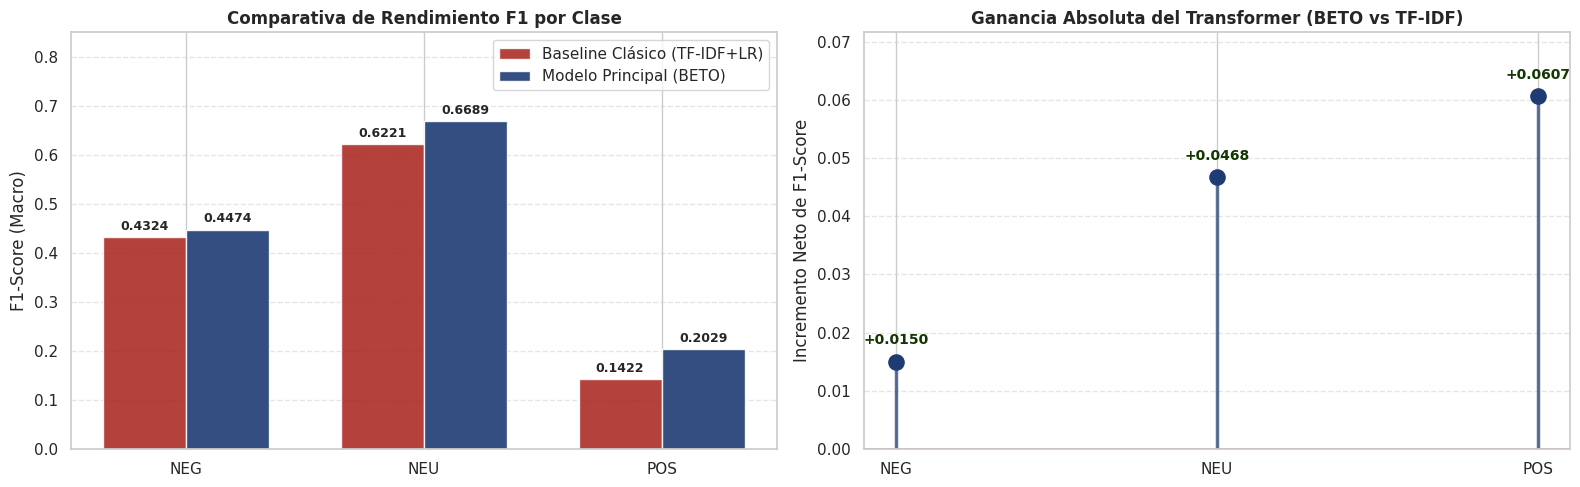

In [27]:
# ==============================================================================
# VISUALIZACIONES EN PARALELO — BASELINE CLÁSICO VS MODELO PRINCIPAL (BETO)
# ==============================================================================
if TASK_TYPE.startswith("classification"):
    print("Gráficos comparativos de rendimiento por clase")

    # 1. Definir los datos reales de rendimiento extraídos de las Secciones 5 y 9
    clases = LABEL_SPACE  # ['NEG', 'NEU', 'POS']

    # F1-Scores reales obtenidos en vuestra consola
    f1_baseline = [0.4324, 0.6221, 0.1422]  # Sección 5
    f1_beto     = [0.4474, 0.6689, 0.2029]  # Sección 9 (Reporte BETO)

    x = np.arange(len(clases))  # Localización de las etiquetas
    width = 0.35                 # Ancho de las barras

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --------------------------------------------------------------------------
    # GRÁFICO 1: Barras Comparativas de F1-Score por Categoría
    # --------------------------------------------------------------------------
    rects1 = axes[0].bar(x - width/2, f1_baseline, width, label='Baseline Clásico (TF-IDF+LR)', color='#A8201A', alpha=0.85)
    rects2 = axes[0].bar(x + width/2, f1_beto, width, label='Modelo Principal (BETO)', color='#1F3B73', alpha=0.9)

    # Añadir etiquetas de texto sobre las barras
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 puntos de desfase vertical
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    autolabel(rects1, axes[0])
    autolabel(rects2, axes[0])

    axes[0].set_ylabel('F1-Score (Macro)')
    axes[0].set_title('Comparativa de Rendimiento F1 por Clase', fontsize=12, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(clases)
    axes[0].set_ylim(0, 0.85)
    axes[0].legend(loc='upper right')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # --------------------------------------------------------------------------
    # GRÁFICO 2: Brecha de Mejora Absoluta (Diseño LolliPop Seguro de Versión)
    # --------------------------------------------------------------------------
    mejoras = np.array(f1_beto) - np.array(f1_baseline)

    # Dibujar líneas verticales desde el suelo (0) hasta el punto de la métrica
    axes[1].vlines(x=clases, ymin=0, ymax=mejoras, color='#1F3B73', linewidth=2.5, alpha=0.7)

    # Dibujar los puntos (nodos superiores) usando un scatter plot estándar
    axes[1].scatter(clases, mejoras, color='#1F3B73', s=120, zorder=3, label='Ganancia Neta')

    # Dibujar la línea base de referencia en el origen
    axes[1].axhline(0, color='#A8201A', linestyle='-', linewidth=1.2, alpha=0.6)

    # Inyectar el valor del delta numérico sobre cada nodo
    for idx, m in enumerate(mejoras):
        axes[1].text(idx, m + (max(mejoras) * 0.04), f'+{m:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#143601')

    axes[1].set_ylabel('Incremento Neto de F1-Score')
    axes[1].set_title('Ganancia Absoluta del Transformer (BETO vs TF-IDF)', fontsize=12, fontweight='bold')
    axes[1].set_ylim(0, max(mejoras) + (max(mejoras) * 0.18))
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig("comparativa_modelos_S9.png", dpi=150, bbox_inches="tight")
    plt.show()

---

## 10 · Declaración de uso de IA (obligatoria)



Durante el desarrollo del miniproyecto se utilizaron herramientas de inteligencia artificial como apoyo técnico y de redacción. La herramienta principal utilizada fue **Gemini**, principalmente para orientar la construcción de celdas de código, revisar errores, mejorar visualizaciones, estructurar explicaciones y apoyar la redacción de interpretaciones. En la etapa final también se utilizó **ChatGPT** para corroborar consistencia del notebook, revisar el cumplimiento de la pauta.

Las herramientas de IA se usaron específicamente en las siguientes partes:

- Apoyo en la organización general del notebook según la pauta del laboratorio.
- Sugerencias para carga, exploración y análisis del dataset.
- Revisión de errores de código y ajustes de compatibilidad en Google Colab.
- Apoyo en visualizaciones exploratorias, análisis de balance de clases, longitudes, vocabulario y calidad de datos.
- Sugerencias para el baseline clásico con TF-IDF y Logistic Regression.
- Apoyo en la redacción e interpretación de resultados.
- Revisión final de consistencia entre métricas, variables globales, `MAX_LENGTH_DECISION`, conclusiones y estructura del entregable.

Las partes realizadas y validadas directamente por el equipo fueron:

- Ejecución completa del notebook en Google Colab.
- Verificación de que las celdas funcionaran correctamente.
- Revisión manual de los resultados obtenidos.
- Selección de las decisiones finales usadas en el notebook.
- Interpretación final de los gráficos, métricas y errores.
- Ajuste de variables, nombres, textos y salidas para que fueran coherentes con el dataset trabajado.
- Decisión de utilizar `MAX_LENGTH_DECISION = 262` en función del análisis exploratorio de longitudes.
- Revisión de que el contenido final fuera defendible y consistente con la pauta del laboratorio.